<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/good_Evaluacion_2_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUACIÓN 2 Preparacion DE DATOS**

Autores: Rodrigo Casanova, Jose Vasquez, Samuel Acuña

Correo Electrónico: rodr.casanova@duocuc.cl, jo.vasquezp@duocuc.cl, sam.acuna@duocuc.cl

Fecha de Creación: Marzo 2026

Versión: 1.0

In [118]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from math import log2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV


# Contexto y Objetivos.

Una empresa de construcción que opera en ciudades como Concepción, Valdivia, Temuco y Punta Arenas busca optimizar la planificación de sus obras considerando las condiciones climáticas.

A partir del análisis de variables como precipitaciones, horas de sol y temperatura, la empresa ajusta sus cronogramas de trabajo para reducir retrasos y mejorar la eficiencia operativa.

# Carga de data


In [119]:
!wget https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv

--2026-05-15 04:01:50--  https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv.2’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.08s   

2026-05-15 04:01:51 (57.2 MB/s) - ‘data_clima_2025_final.csv.2’ saved [4527300/4527300]



In [120]:
data = pd.read_csv("data_clima_2025_final.csv", sep=",", low_memory = False)
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


## Exploración inicial del dataset

Detección de nulos

In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

In [122]:
data.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,latitud,longitud,is_rainy_hour
count,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000
mean,10.644075,79.042842,8.337603,0.138981,62.114977,11.930189,205.227225,0.136601,0.495882,1221.216663,-42.134914,-72.448638,0.184714
std,5.213359,16.228987,6.350746,0.582210,41.871036,8.474665,101.410042,0.577866,0.499991,1650.360797,6.456137,0.920869,0.388071
min,-5.100000,15.230701,-8.741941,0.000000,0.000000,0.000000,0.367278,0.000000,0.000000,0.000000,-53.162569,-73.245986,0.000000
25%,7.050000,68.349886,3.876656,0.000000,13.000000,5.649248,139.531913,0.000000,0.000000,0.000000,-43.151237,-73.099151,0.000000
50%,10.400000,82.217838,8.232820,0.000000,88.000000,9.940824,229.398790,0.000000,0.000000,0.000000,-39.275008,-72.820372,0.000000
75%,13.700000,92.891105,12.350445,0.000000,100.000000,15.882896,284.036250,0.000000,1.000000,3600.000000,-38.258686,-72.169859,0.000000
max,31.750000,100.000000,32.108310,13.200000,100.000000,65.250920,360.000000,13.200000,1.000000,3600.000000,-36.827070,-70.907822,1.000000


In [123]:
data.shape

(33024, 15)

## Interpretacion

El conjunto de datos contiene 33.024 registros y 15 variables. Se identifican variables numéricas asociadas a mediciones climáticas, como temperatura, humedad, precipitación y viento, además de variables categóricas como la localidad.

La función `data.info()` permite revisar la estructura del dataset, los tipos de datos y la existencia de valores nulos. Por otro lado, `data.shape` confirma la dimensión del conjunto de datos.

# Identificación de valores nulos y duplicados

In [124]:
# Revisa la existencia de duplicados
data.duplicated().sum()


np.int64(0)

## Interpretacion

Se revisó la existencia de registros duplicados dentro del conjunto de datos.

Los resultados indican que no existen filas duplicadas, por lo que cada observación corresponde a un registro único y no es necesario aplicar procesos de eliminación de duplicados.

In [125]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


## Interpretacion

Se realizó una revisión de valores nulos utilizando la función `isnull().sum()`.

Los resultados muestran que el conjunto de datos no presenta valores faltantes en ninguna de sus variables, lo que indica que el dataset está completo y no requiere procesos de imputación en esta etapa.

## Inconsistencias

In [126]:
for columna in ["relative_humidity_2m", "precipitation", "cloud_cover","wind_speed_10m","wind_direction_10m","rain","is_day","sunshine_duration","is_rainy_hour"]:
  print(f"{columna : <20} tiene {len(data[data[columna] < 0])} valores negativos")

relative_humidity_2m tiene 0 valores negativos
precipitation        tiene 0 valores negativos
cloud_cover          tiene 0 valores negativos
wind_speed_10m       tiene 0 valores negativos
wind_direction_10m   tiene 0 valores negativos
rain                 tiene 0 valores negativos
is_day               tiene 0 valores negativos
sunshine_duration    tiene 0 valores negativos
is_rainy_hour        tiene 0 valores negativos


In [127]:
print("Humedad fuera de rango:",
      len(data[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100)]))

print("Dirección viento fuera de rango:",
      len(data[(data['wind_direction_10m'] < 0) | (data['wind_direction_10m'] > 360)]))

Humedad fuera de rango: 0
Dirección viento fuera de rango: 0


## Interpretacion
Se realizó una validación de consistencia para identificar posibles valores fuera de rango o inconsistentes dentro del conjunto de datos.

Los resultados muestran que no existen valores negativos en las variables analizadas y tampoco se detectaron registros fuera de los rangos esperados para humedad relativa y dirección del viento.

Esto indica que los datos presentan consistencia y no evidencian errores aparentes en sus valores.

Detección de valores atípicos

In [193]:
def buscar_atipicos(data: pd.DataFrame, columna: str) -> pd.DataFrame:

    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return data[
        (data[columna] < limite_inferior) |
        (data[columna] > limite_superior)
    ]


def obtener_cantidad_atipicos(data: pd.DataFrame, columnas: list) -> dict:

    total_atipicos = {}

    for columna in columnas:
        atipicos = buscar_atipicos(data, columna)
        total_atipicos[columna] = atipicos.shape[0]

    return total_atipicos


columnas_atipicos = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'cloud_cover',
    'wind_speed_10m',
    'wind_direction_10m',
    'rain',
    'sunshine_duration'
]

atipicos_por_columna = obtener_cantidad_atipicos(data, columnas_atipicos)

for columna, cantidad in atipicos_por_columna.items():
    print(f"{columna:<30} → {cantidad} valores atípicos")

temperature_2m                 → 476 valores atípicos
relative_humidity_2m           → 133 valores atípicos
precipitation                  → 6147 valores atípicos
cloud_cover                    → 0 valores atípicos
wind_speed_10m                 → 1241 valores atípicos
wind_direction_10m             → 0 valores atípicos
rain                           → 6095 valores atípicos
sunshine_duration              → 0 valores atípicos


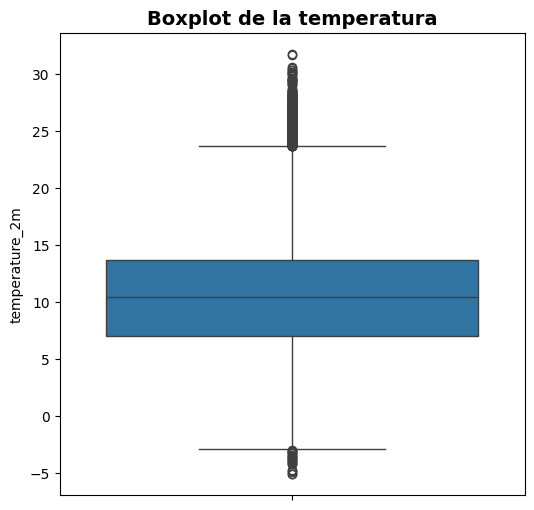

In [194]:
plt.figure(figsize=(6,6))

sb.boxplot(y=data['temperature_2m'])

plt.title(
    'Boxplot de la temperatura',
    fontsize=14,
    fontweight='bold'
)

plt.show()

## Interpretacion

Se realizó una detección de valores atípicos utilizando el método del rango intercuartílico (IQR).

Los resultados muestran presencia de valores extremos en variables como precipitación, temperatura y velocidad del viento. En el caso de variables climáticas, estos valores pueden representar eventos reales y no necesariamente errores.

El boxplot de la temperatura permite visualizar la distribución de la variable y confirmar la existencia de valores extremos tanto inferiores como superiores.

Debido a la naturaleza del problema, los valores atípicos no fueron eliminados directamente, ya que podrían representar fenómenos climáticos válidos.

## Creación de variables temporales y transformación cíclica

In [195]:
data["fecha"] = pd.to_datetime(data["date"])

data["hora"] = data["fecha"].dt.hour
data["mes"] = data["fecha"].dt.month

data[["fecha", "hora", "mes"]].head()

,fecha,hora,mes
24,2025-01-02 03:00:00+00:00,3,1
24792,2025-01-02 03:00:00+00:00,3,1
8280,2025-01-02 03:00:00+00:00,3,1
16536,2025-01-02 03:00:00+00:00,3,1
24793,2025-01-02 04:00:00+00:00,4,1


## Interpretacion

A partir de la variable de fecha se generaron nuevas variables correspondientes a la hora y al mes.

Estas variables permiten realizar análisis temporales y detectar patrones asociados al comportamiento climático según distintos periodos del día y meses del año.

In [196]:
data["hora_sin"] = np.sin(2 * np.pi * data["hora"] / 24)
data["hora_cos"] = np.cos(2 * np.pi * data["hora"] / 24)

data["mes_sin"] = np.sin(2 * np.pi * data["mes"] / 12)
data["mes_cos"] = np.cos(2 * np.pi * data["mes"] / 12)

data[[
    "hora",
    "hora_sin",
    "hora_cos",
    "mes",
    "mes_sin",
    "mes_cos"
]].head()

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
24,3,0.707107,0.707107,1,0.5,0.866025
24792,3,0.707107,0.707107,1,0.5,0.866025
8280,3,0.707107,0.707107,1,0.5,0.866025
16536,3,0.707107,0.707107,1,0.5,0.866025
24793,4,0.866025,0.500000,1,0.5,0.866025


## Interpretacion

Se aplicó una transformación cíclica a las variables hora y mes utilizando funciones seno y coseno.

Este tipo de transformación permite representar correctamente variables temporales con comportamiento circular, evitando interpretar como lejanos valores que realmente son cercanos, como las 23:00 y las 00:00 horas o diciembre y enero.

La transformación cíclica mejora la representación temporal de los datos para futuros modelos predictivos.

## Creación de ventanas de tiempo y rezagos

## Ordenar los datos

In [198]:
data = data.sort_values(["Localidad", "fecha"])

## Crear rezagos (lags)

In [202]:
data["temp_lag_1h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(1)
)

data["temp_lag_12h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(12)
)

data["temp_lag_24h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(24)
)

## Crear ventanas móviles (rolling)

In [203]:
data["temp_rolling_6h"] = (
    data.groupby("Localidad")["temperature_2m"]
    .shift(1)
    .rolling(6)
    .mean()
    .reset_index(0, drop=True)
)

data["lluvia_rolling_24h"] = (
    data.groupby("Localidad")["precipitation"]
    .shift(1)
    .rolling(24)
    .sum()
    .reset_index(0, drop=True)
)

## Revisar nuevos nulos

In [205]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


## Eliminar nulos generados

In [204]:
data = data.dropna().copy()

In [206]:
data[[
    "temperature_2m",
    "temp_lag_1h",
    "temp_lag_24h",
    "temp_rolling_6h",
    "lluvia_rolling_24h"
]].head()

,temperature_2m,temp_lag_1h,temp_lag_24h,temp_rolling_6h,lluvia_rolling_24h
72,14.45,14.95,17.45,18.316667,0.0
73,14.15,14.45,17.20,17.608333,0.0
74,13.95,14.15,16.80,16.900000,0.0
75,13.65,13.95,16.20,16.225000,0.0
76,13.35,13.65,15.65,15.641667,0.0


## Interpretacion

Se generaron variables de rezago y ventanas móviles con el objetivo de incorporar comportamiento temporal al modelo.

Los rezagos permiten utilizar información de periodos anteriores, mientras que las ventanas móviles resumen el comportamiento reciente de variables como temperatura y precipitación.

Para evitar fuga de información, las ventanas fueron construidas utilizando únicamente datos pasados mediante el uso de `shift(1)`.

Debido a la creación de estas nuevas variables, se generaron valores nulos al inicio de cada serie temporal, los cuales fueron eliminados posteriormente.

## Definición de variables predictoras y variable objetivo

In [207]:
target = "temperature_2m"

features = [
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "is_day",
    "sunshine_duration",
    "Localidad",
    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos",
    "temp_rolling_6h",
    "lluvia_rolling_24h",
    "temp_lag_1h",
    "temp_lag_12h",
    "temp_lag_24h"
]

X = data[features]

y = data[target]

In [208]:
X.head()

,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,is_day,sunshine_duration,Localidad,hora_sin,hora_cos,mes_sin,mes_cos,temp_rolling_6h,lluvia_rolling_24h,temp_lag_1h,temp_lag_12h,temp_lag_24h
72,92.506386,0.0,73.0,4.514377,355.42615,0.0,0.0,"Concepción, Chile",0.707107,7.071068e-01,0.5,0.866025,18.316667,0.0,14.95,21.95,17.45
73,94.011894,0.0,100.0,4.627786,346.50424,0.0,0.0,"Concepción, Chile",0.866025,5.000000e-01,0.5,0.866025,17.608333,0.0,14.45,22.00,17.20
74,95.549510,0.0,100.0,4.724786,342.25522,0.0,0.0,"Concepción, Chile",0.965926,2.588190e-01,0.5,0.866025,16.900000,0.0,14.15,22.05,16.80
75,97.111885,0.0,100.0,5.081613,337.06787,0.0,0.0,"Concepción, Chile",1.000000,6.123234e-17,0.5,0.866025,16.225000,0.0,13.95,22.15,16.20
76,97.105200,0.0,100.0,5.810404,343.81070,0.0,0.0,"Concepción, Chile",0.965926,-2.588190e-01,0.5,0.866025,15.641667,0.0,13.65,21.60,15.65


In [209]:
y.head()

,temperature_2m
72,14.45
73,14.15
74,13.95
75,13.65
76,13.35


## Interpretacion

Se definió como variable objetivo la temperatura (`temperature_2m`), mientras que las demás variables fueron utilizadas como predictoras.

Las variables seleccionadas incluyen información climática, geográfica y temporal, además de rezagos y ventanas móviles, permitiendo incorporar comportamiento histórico al modelo.

La variable `apparent_temperature` fue excluida para evitar alta correlación con la variable objetivo y reducir posibles problemas de colinealidad.

## División de datos en entrenamiento y prueba

In [210]:
data = data.sort_values("fecha")

limite = int(len(data) * 0.8)

train = data.iloc[:limite]
test = data.iloc[limite:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (25785, 17)
X_test: (6447, 17)
y_train: (25785,)
y_test: (6447,)


## Interpretacion

El conjunto de datos fue dividido en entrenamiento y prueba utilizando una separación temporal.

Se utilizó el 80% de los registros para entrenamiento y el 20% restante para evaluación.

Esta estrategia permite evitar fuga de información, ya que el modelo se entrena utilizando datos pasados y se evalúa con datos posteriores, simulando un escenario más realista de predicción.

## Clases y funciones personalizadas para preparación de datos

### Tratamiento de atipico

In [211]:
class Winsorizer(BaseEstimator, TransformerMixin):

    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):

        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])

        return self

    def transform(self, X):

        X = pd.DataFrame(X, columns=self.columns_)

        for col in self.columns_:

            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])

            X[col] = np.clip(X[col], lower, upper)

        return X.values

    def get_feature_names_out(self, input_features=None):

        if input_features is None:
            return np.array(self.columns_)

        return np.array(input_features)

### Tratamiento de duplicados

In [212]:
def tratar_duplicados(X: pd.DataFrame, drop=False):

    return X.drop_duplicates() if drop else X

### Correlacion

In [213]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.9):

        self.threshold = threshold
        self.columns_to_drop_ = None

    def fit(self, X, y=None):

        X_df = pd.DataFrame(X)

        corr_matrix = X_df.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.columns_to_drop_ = [
            col for col in upper.columns
            if any(upper[col] > self.threshold)
        ]

        return self

    def transform(self, X):

        X_df = pd.DataFrame(X)

        X_filtered = X_df.drop(
            columns=self.columns_to_drop_,
            errors="ignore"
        )

        return X_filtered.values

## Interpretacion

Se implementaron clases y funciones personalizadas para mejorar la preparación de los datos antes del entrenamiento de los modelos.

La clase `Winsorizer` permite reducir el impacto de valores extremos mediante winsorización, limitando los valores atípicos sin eliminar registros.

La función `tratar_duplicados` permite controlar la existencia de registros repetidos dentro del pipeline.

Por otro lado, la clase `CorrelationFilter` permite identificar y eliminar variables altamente correlacionadas, reduciendo problemas de colinealidad y mejorando la estabilidad del modelo.

## Preprocesamiento de variables cuantitativas y cualitativas

In [214]:
features_cat = ["Localidad", "is_day"]

numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.05, 0.05))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, [col for col in features if col not in features_cat]),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="drop"
)

## Interpretacion

Se definió un preprocesamiento diferenciado para variables cuantitativas y cualitativas.

En las variables cuantitativas se aplicó winsorización para reducir el efecto de valores atípicos, imputación mediante la media para manejar posibles valores faltantes y estandarización para dejar las variables en una escala comparable.

En las variables cualitativas se aplicó imputación con la categoría más frecuente y codificación OneHotEncoder, permitiendo que estas variables puedan ser utilizadas por los modelos de regresión.

## Definición de pipelines de modelamiento

In [215]:
pipeline_lr_temperature = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LinearRegression())
])

pipeline_dt_temperature = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=15,
        min_samples_leaf=7,
        random_state=29
    ))
])

In [216]:
pipeline_lr_temperature

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'precipitation',
                                                   'cloud_cover',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m',
                                                   'sunshine_duration',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_rolling_6h',
                                                   'lluvia_rolling_24h',
                                                   'temp_lag_1h',
                                                   'temp_lag_12h',
                                                   'temp_lag_24h']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

In [217]:
pipeline_dt_temperature

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'precipitation',
                                                   'cloud_cover',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m',
                                                   'sunshine_duration',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_rolling_6h',
                                                   'lluvia_rolling_24h',
                                                   'temp_lag_1h',
                                                   'temp_lag_12h',
                                                   'temp_lag_24h']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day'])])),
                ('modelo',
                 DecisionTreeRegressor(max_depth=12, min_samples_leaf=7,
                                       min_samples_split=15,
                                       random_state=29))])

### Interpretacion
Se construyeron dos pipelines de modelamiento para predecir la variable `temperature_2m`.

El primer pipeline utiliza un modelo de regresión lineal, incorporando preprocesamiento de variables y filtrado de colinealidad.

El segundo pipeline utiliza un árbol de decisión regresor con parámetros controlados para reducir el riesgo de sobreajuste.

El uso de pipelines permite integrar la preparación de datos y el entrenamiento del modelo en un único flujo, evitando malas prácticas como aplicar transformaciones antes de la división de los datos.

## Entrenamiento de los modelos

In [218]:
pipeline_lr_temperature.fit(X_train, y_train)
pipeline_dt_temperature.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'precipitation',
                                                   'cloud_cover',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m',
                                                   'sunshine_duration',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_rolling_6h',
                                                   'lluvia_rolling_24h',
                                                   'temp_lag_1h',
                                                   'temp_lag_12h',
                                                   'temp_lag_24h']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day'])])),
                ('modelo',
                 DecisionTreeRegressor(max_depth=12, min_samples_leaf=7,
                                       min_samples_split=15,
                                       random_state=29))])

### Interpretacion

Se entrenaron los modelos de regresión utilizando únicamente el conjunto de entrenamiento.

Esto permite que las transformaciones del pipeline, como imputación, escalado, winsorización y codificación de variables categóricas, se ajusten solo con los datos de entrenamiento, evitando fuga de información hacia el conjunto de prueba.

## Evaluación de modelos

In [219]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados = {
        "Modelo": nombre,
        "R2 Train": r2_score(y_train, pred_train),
        "R2 Test": r2_score(y_test, pred_test),
        "MAE Train": mean_absolute_error(y_train, pred_train),
        "MAE Test": mean_absolute_error(y_test, pred_test)
    }

    return resultados

In [220]:
resultados = [
    evaluar_modelo(
        "LinearRegression",
        pipeline_lr_temperature,
        X_train,
        y_train,
        X_test,
        y_test
    ),

    evaluar_modelo(
        "DecisionTreeRegressor",
        pipeline_dt_temperature,
        X_train,
        y_train,
        X_test,
        y_test
    )
]

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados

,Modelo,R2 Train,R2 Test,MAE Train,MAE Test
0,LinearRegression,0.964917,0.956185,0.661330,0.671867
1,DecisionTreeRegressor,0.990132,0.965454,0.353436,0.572457


### Interpretacion

Los resultados muestran un desempeño alto en ambos modelos, obteniendo valores elevados de R² y bajos errores MAE tanto en entrenamiento como en prueba.

La diferencia entre métricas de entrenamiento y prueba es reducida, lo que indica que los modelos presentan buena capacidad de generalización y no evidencian un sobreajuste significativo.

En particular, el modelo DecisionTreeRegressor presenta un desempeño ligeramente superior en términos de error absoluto medio.

## Predicción de una nueva observación

### Seleccionar una observación del conjunto de prueba

In [152]:
nueva_observacion = X_test.iloc[[0]]


## Predicción con LinearRegression

In [153]:
pred_lr = pipeline_lr_temperature.predict(nueva_observacion)

print("Predicción LinearRegression:", pred_lr[0])

Predicción LinearRegression: 10.335808034379738


### Predicción con DecisionTreeRegressor

In [154]:
pred_dt = pipeline_dt_temperature.predict(nueva_observacion)

print("Predicción DecisionTreeRegressor:", pred_dt[0])

Predicción DecisionTreeRegressor: 10.237333166666668


### Valor real

In [155]:
valor_real = y_test.iloc[0]

print("Valor real:", valor_real)

Valor real: 10.55


### Interpretacion

Se realizó una predicción utilizando una observación del conjunto de prueba con el objetivo de comparar el valor real de la temperatura con las predicciones generadas por ambos modelos.

Los resultados muestran que tanto LinearRegression como DecisionTreeRegressor logran aproximarse adecuadamente al valor real, evidenciando la capacidad predictiva de los modelos entrenados.

## Dataset preparado para modelamiento

In [156]:
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,...,hora_cos,mes_sin,mes_cos,temp_lag_1h,temp_lag_2h,temp_lag_3h,temp_lag_12h,temp_lag_24h,temp_rolling_6h,lluvia_rolling_24h
24,2025-01-02 03:00:00+00:00,16.650,70.216034,15.285278,0.0,0.0,11.897714,190.45985,0.0,0.0,...,0.707107,0.5,0.866025,16.800,15.950,16.950,20.050,15.100000,18.416667,0.0
24792,2025-01-02 03:00:00+00:00,10.962,89.258700,7.079889,0.8,100.0,25.319290,305.15894,0.8,0.0,...,0.707107,0.5,0.866025,11.162,11.562,11.812,15.012,11.562000,18.658333,0.0
8280,2025-01-02 03:00:00+00:00,11.100,86.605225,9.660133,0.0,0.0,7.993298,262.23492,0.0,0.0,...,0.707107,0.5,0.866025,12.050,13.300,15.150,18.400,10.600000,11.903666,3.7
16536,2025-01-02 03:00:00+00:00,13.350,73.199036,11.111574,0.0,0.0,12.921192,161.31256,0.0,0.0,...,0.707107,0.5,0.866025,14.700,16.100,17.850,18.550,12.150000,16.200000,0.0
24793,2025-01-02 04:00:00+00:00,11.062,88.668260,7.280637,0.3,100.0,24.628447,305.78116,0.3,0.0,...,0.500000,0.5,0.866025,10.962,11.162,11.562,16.212,11.111999,17.200000,0.0


In [157]:
data.shape

(32928, 29)

In [158]:
data.to_csv("data_modelo_G1.csv", index=False)

### Interpretacion

Luego del proceso de preparación de datos, el dataset final incorpora variables originales, transformaciones temporales, rezagos y ventanas móviles.

El conjunto de datos preparado se encuentra listo para ser utilizado en procesos de modelamiento predictivo.

Finalmente, el dataset fue exportado en formato CSV para facilitar su reutilización y trazabilidad.

In [160]:
# 1. Definimos el Pipeline (mantenemos tu estructura ganadora)
pipeline_stress = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": False})),
    ("preprocesamiento", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.98)), # Umbral alto para procesar más datos
    ("modelo", DecisionTreeRegressor(random_state=29))
])

# 2. El "Grid" de la muerte: Tiramos todos los parámetros posibles
# Esta combinación generará cientos de modelos para entrenar
param_grid_stress = {
    'modelo__max_depth': [10, 15],
    'modelo__min_samples_split': [2],
    'modelo__min_samples_leaf': [1, 4],
    'modelo__criterion': ['squared_error'],
    'modelo__splitter': ['best']
}

# 3. Configuración de GridSearchCV para máximo estrés
# cv=10: Entrenará cada modelo 10 veces (el doble de trabajo)
# n_jobs=-1: Usará el 100% de los núcleos del procesador del Duoc
grid_search_stress = GridSearchCV(
    pipeline_stress,
    param_grid_stress,
    cv=10,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=3 # Para que veas en tiempo real cómo sufre el PC
)

# 4. ¡A correr el estrés!
print("Iniciando prueba de estrés... Prepárate para escuchar los ventiladores.")
grid_search_stress.fit(X_train, y_train)

# 5. Resultados finales[cite: 2]
best_stress_model = grid_search_stress.best_estimator_
y_pred_final = best_stress_model.predict(X_test)

print(f"\n--- RESULTADO DE LA PRUEBA DEFINITIVA ---")
print(f"MAE final: {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"R² final: {r2_score(y_test, y_pred_final):.4f}")
print(f"Mejores parámetros: {grid_search_stress.best_params_}")

Iniciando prueba de estrés... Prepárate para escuchar los ventiladores.
Fitting 10 folds for each of 4 candidates, totalling 40 fits

--- RESULTADO DE LA PRUEBA DEFINITIVA ---
MAE final: 0.5635
R² final: 0.9668
Mejores parámetros: {'modelo__criterion': 'squared_error', 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 2, 'modelo__splitter': 'best'}


Tratamiento de atipicos

In [161]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X[col] = np.clip(X[col], lower, upper)
    return X.values

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

# Tratamiento de duplicados

Correlacion

In [163]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

X__train y Test

In [164]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

# Entrenamiento
pipeline_lr_temperature.fit(X_train, y_train)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7b3bbab47420>,
                                     kw_args={'drop': False})),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b3bbb087aa0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_rainy_hour',
                                                   'is_day'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

Pipeline

Definimos los pipeline

In [165]:
pipeline_dt_temperature.fit(X_train, y_train)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7b3bbab47420>,
                                     kw_args={'drop': False})),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b3bbb087aa0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_rainy_hour',
                                                   'is_day'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo',
                 DecisionTreeRegressor(max_depth=10, random_state=29))])

In [166]:
# Predicciones
y_pred = pipeline_lr_temperature.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo Linear regresor---")
print(f"{'R²' :<15}: {r2:.3f}")
print(f"{'MAE':<15}: {mae:,.2f}")


--- Métricas del modelo Linear regresor---
R²             : 0.962
MAE            : 0.67


In [167]:
# Predicciones
y_pred = pipeline_dt_temperature.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo Decision Tree Regresor ---")
print(f"{'R²' :<15}: {r2:.3f}")
print(f"{'MAE':<15}: {mae:,.2f}")


--- Métricas del modelo Decision Tree Regresor ---
R²             : 0.975
MAE            : 0.54


In [168]:
# Variables que fueron eliminadas por presentar colinealidad
pipeline_lr_temperature.named_steps["colinealidad"].columns_to_drop_

[5, 9, 18, 19, 22, 25, 26]

In [169]:
X_train.columns

Index(['relative_humidity_2m', 'precipitation', 'cloud_cover',
       'wind_speed_10m', 'wind_direction_10m', 'rain', 'is_day',
       'sunshine_duration', 'Localidad', 'latitud', 'longitud',
       'is_rainy_hour', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
       'temp_rolling_6h', 'lluvia_rolling_24h', 'temp_lag_1h', 'temp_lag_2h',
       'temp_lag_3h', 'temp_lag_12h', 'temp_lag_24h'],
      dtype='object')

In [176]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    r2_train = r2_score(y_train, pred_train)
    r2_test = r2_score(y_test, pred_test)

    mae_train = mean_absolute_error(y_train, pred_train)
    mae_test = mean_absolute_error(y_test, pred_test)

    diferencia_r2 = abs(r2_train - r2_test)
    diferencia_mae = abs(mae_train - mae_test)

    if diferencia_r2 <= 0.05 and diferencia_mae <= 0.20:
        estado = "Sin evidencia fuerte de sobreentrenamiento"
    elif r2_train > r2_test and diferencia_r2 > 0.05:
        estado = "Posible sobreentrenamiento"
    else:
        estado = "Revisar desempeño"

    return {
        "Modelo": nombre,
        "R2 Train": r2_train,
        "R2 Test": r2_test,
        "MAE Train": mae_train,
        "MAE Test": mae_test,
        "Diferencia R2": diferencia_r2,
        "Diferencia MAE": diferencia_mae,
        "Estado": estado
    }

In [184]:
resultados = [
    evaluar_modelo("LinearRegression", pipeline_lr_temperature, X_train, y_train, X_test, y_test),
    evaluar_modelo("DecisionTreeRegressor", pipeline_dt_temperature, X_train, y_train, X_test, y_test)
]

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados.round(4)

,Modelo,R2 Train,R2 Test,MAE Train,MAE Test
0,LinearRegression,0.9639,0.9617,0.6646,0.6696
1,DecisionTreeRegressor,0.9970,0.9724,0.1795,0.5741
